# Manhattan Routing Primitives

This page covers the low-level building blocks that power all of kfactory's
manhattan (right-angle) routing.  `route_bundle` wraps these internally — read
this page when you need fine-grained control over backbone paths or want to
understand how routing works under the hood.

| Function | Purpose |
|---|---|
| `kf.routing.manhattan.route_manhattan` | Calculate a 2-port backbone (list of `kdb.Point`) |
| `kf.routing.manhattan.route_manhattan_180` | Backbone for a U-turn between two co-directional ports |
| `kf.routing.optical.place_manhattan` | Materialise a backbone into waveguide geometry |
| `kf.routing.steps.*` | Step objects to control entry / exit behaviour |

## What is a backbone?

A **backbone** is a list of `kdb.Point` objects (DBU coordinates) that describe the
centreline of a route — the corners where bends will be placed.  Separating path
*calculation* from *placement* lets you inspect or manipulate the route before
committing geometry to a cell.

## Setup

In [1]:
from functools import partial

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
kf.kcl.infos = L

# Euler bend: width=0.5 µm, nominal radius=10 µm.
# The actual routing radius is larger than the nominal — always use get_radius().
wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD", sections=[(L.WGCLAD, 0, 2_000)])
)
bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=wg_enc,
    angle=90,
)
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

WG_WIDTH = kf.kcl.to_dbu(0.5)       # 500 DBU
BEND_RADIUS = kf.routing.optical.get_radius(bend90)  # actual footprint radius in DBU

print(f"WG width:    {WG_WIDTH} DBU  ({WG_WIDTH / 1000:.3f} µm)")
print(f"Bend radius: {BEND_RADIUS} DBU  ({BEND_RADIUS / 1000:.3f} µm)")

WG width:    500 DBU  (0.500 µm)
Bend radius: 18701 DBU  (18.701 µm)


## 1 · `route_manhattan` — backbone calculation

`route_manhattan(port1, port2, bend90_radius)` returns the shortest set of
axis-aligned waypoints connecting two ports.  No geometry is created yet.

The `bend90_radius` must be the **actual footprint** radius of the bend cell
(use `kf.routing.optical.get_radius(bend_cell)`).  Passing the nominal radius
of an euler bend will produce collisions because the euler footprint is larger.

In [2]:
# Port 1: North-facing at origin
# Port 2: South-facing offset to the right and above
p_start = kf.Port(
    name="p1",
    trans=kf.kdb.Trans(1, False, 0, 0),          # angle=1 → North
    width=WG_WIDTH,
    layer_info=L.WG,
)
p_end = kf.Port(
    name="p2",
    trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(80), kf.kcl.to_dbu(300)),  # South
    width=WG_WIDTH,
    layer_info=L.WG,
)

backbone = kf.routing.manhattan.route_manhattan(p_start, p_end, bend90_radius=BEND_RADIUS)
print("Backbone points (DBU):", backbone)
print("Backbone points (µm): ", [(p.x / 1000, p.y / 1000) for p in backbone])

Backbone points (DBU): [0,0, 0,18701, 80000,18701, 80000,300000]
Backbone points (µm):  [(0.0, 0.0), (0.0, 18.701), (80.0, 18.701), (80.0, 300.0)]


## 2 · `place_manhattan` — materialise geometry

`place_manhattan(c, p1, p2, pts, ...)` walks the backbone, inserting bend and
straight cells at each waypoint.  The result is placed inside cell `c`.

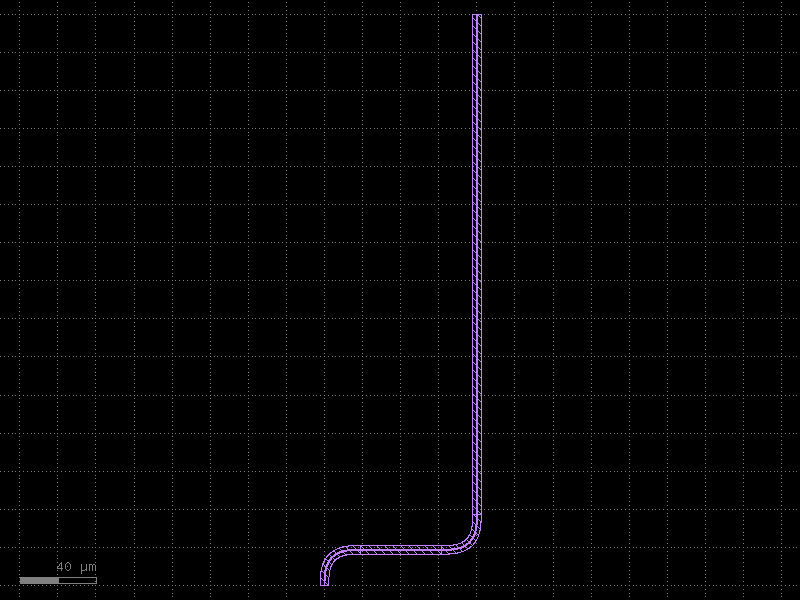

In [3]:
c_basic = kf.KCell("manhattan_basic")

kf.routing.optical.place_manhattan(
    c_basic,
    p_start,
    p_end,
    backbone,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_basic

## 3 · Entry / exit stubs with Steps

Steps let you force a minimum straight section **before** the router takes its
first bend (`start_steps`) or **after** the last bend (`end_steps`).

Common step types:

| Class | Effect |
|---|---|
| `Straight(dist=N)` | Go straight for N DBU |
| `Left()` | Turn left, then continue |
| `Right()` | Turn right, then continue |

Import from `kfactory.routing.steps`:

Backbone with 30 µm stubs (µm): [(0.0, 0.0), (0.0, 48.701), (80.0, 48.701), (80.0, 300.0)]


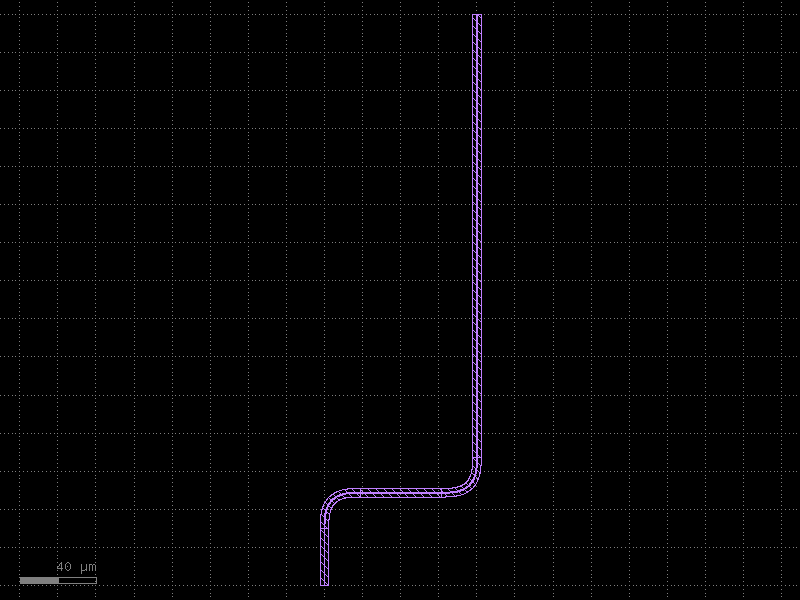

In [4]:
from kfactory.routing.steps import Left, Right, Straight

# Force a 30 µm straight stub at both ends before bending
backbone_stubs = kf.routing.manhattan.route_manhattan(
    p_start,
    p_end,
    bend90_radius=BEND_RADIUS,
    start_steps=[Straight(dist=kf.kcl.to_dbu(30))],
    end_steps=[Straight(dist=kf.kcl.to_dbu(30))],
)
print("Backbone with 30 µm stubs (µm):", [(p.x / 1000, p.y / 1000) for p in backbone_stubs])

c_stubs = kf.KCell("manhattan_stubs")
kf.routing.optical.place_manhattan(
    c_stubs,
    p_start,
    p_end,
    backbone_stubs,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_stubs

Forcing a left turn exit before bending:

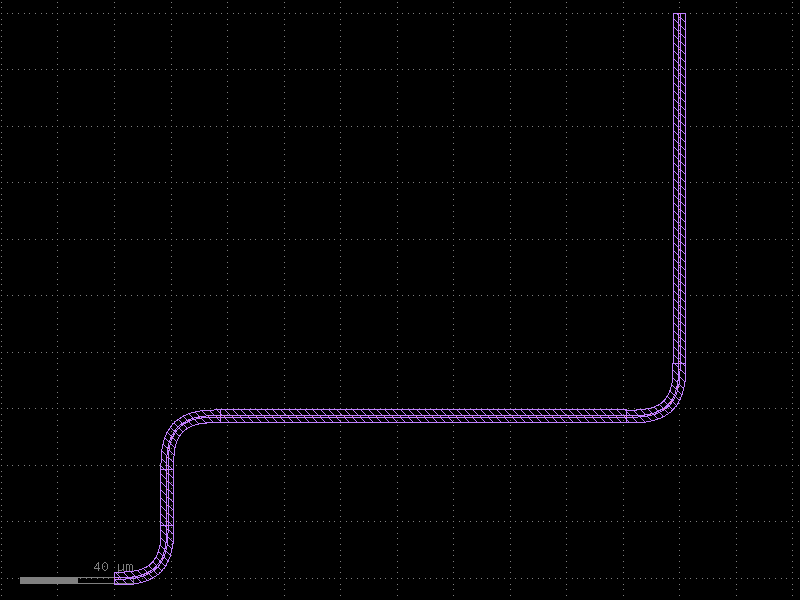

In [5]:
# Start facing East, then force an immediate left (North) exit stub before routing
p_east = kf.Port(
    name="east_start",
    trans=kf.kdb.Trans(0, False, 0, 0),           # angle=0 → East
    width=WG_WIDTH,
    layer_info=L.WG,
)
p_north_end = kf.Port(
    name="north_end",
    trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(200), kf.kcl.to_dbu(200)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

backbone_left = kf.routing.manhattan.route_manhattan(
    p_east,
    p_north_end,
    bend90_radius=BEND_RADIUS,
    start_steps=[Left(), Straight(dist=kf.kcl.to_dbu(20))],
)

c_left = kf.KCell("manhattan_left_exit")
kf.routing.optical.place_manhattan(
    c_left,
    p_east,
    p_north_end,
    backbone_left,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_left

## 4 · `route_manhattan_180` — U-turn routing

When two ports face the **same** direction with one behind the other, a normal
manhattan route needs a 180° U-turn.  `route_manhattan_180` calculates this
backbone efficiently by using a tighter `bend180_radius` (half the leg spacing).

Parameters (all in **DBU**):

- `bend90_radius` — footprint radius for 90° bends (use `get_radius`)
- `bend180_radius` — half the gap between the two parallel U-turn legs
- `start_straight` / `end_straight` — minimum entry / exit straight lengths

U-turn backbone (µm): [(10.0, 0.0), (28.701, 0.0), (28.701, 40.0), (0.0, 40.0)]


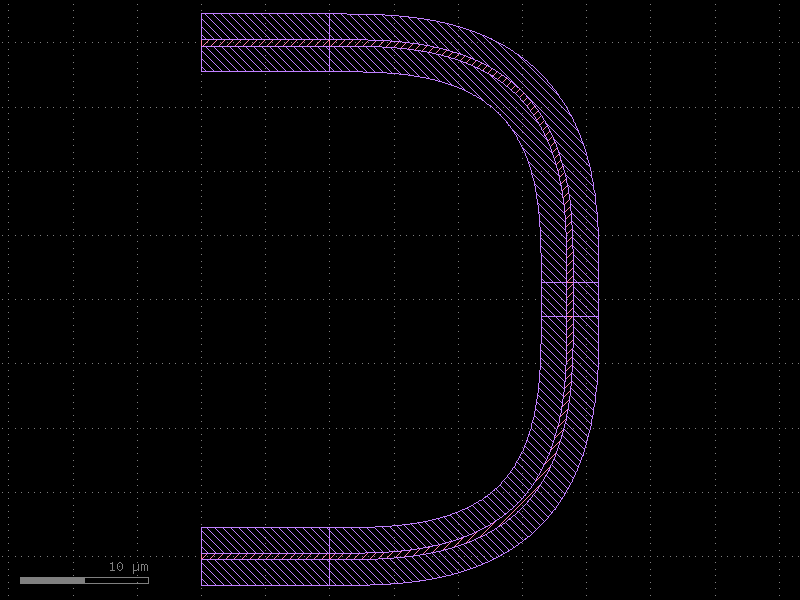

In [6]:
# Two East-facing ports on the same horizontal axis — standard U-turn scenario
p_a = kf.Port(
    name="a",
    trans=kf.kdb.Trans(0, False, 0, 0),           # East at origin
    width=WG_WIDTH,
    layer_info=L.WG,
)
p_b = kf.Port(
    name="b",
    trans=kf.kdb.Trans(0, False, 0, kf.kcl.to_dbu(40)),  # East, 40 µm above
    width=WG_WIDTH,
    layer_info=L.WG,
)

backbone_180 = kf.routing.manhattan.route_manhattan_180(
    p_a,
    p_b,
    bend90_radius=BEND_RADIUS,
    bend180_radius=kf.kcl.to_dbu(40),   # gap between legs
    start_straight=kf.kcl.to_dbu(10),
    end_straight=kf.kcl.to_dbu(10),
)
print("U-turn backbone (µm):", [(p.x / 1000, p.y / 1000) for p in backbone_180])

c_180 = kf.KCell("manhattan_180_uturn")
kf.routing.optical.place_manhattan(
    c_180,
    p_a,
    p_b,
    backbone_180,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_180

## 5 · Inspecting `ManhattanRoute`

`place_manhattan` returns a `ManhattanRoute` object.  You can query it for
inserted instances and length information.

Route length:   298.03 µm
Num instances:  4


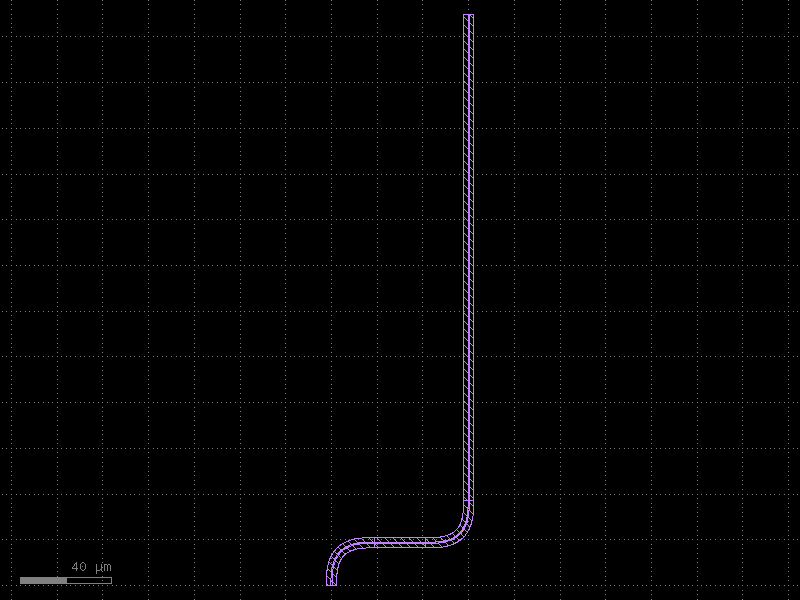

In [7]:
c_info = kf.KCell("manhattan_info")
p1_info = kf.Port(
    name="o1",
    trans=kf.kdb.Trans(1, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
p2_info = kf.Port(
    name="o2",
    trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(60), kf.kcl.to_dbu(250)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

pts_info = kf.routing.manhattan.route_manhattan(p1_info, p2_info, bend90_radius=BEND_RADIUS)
route = kf.routing.optical.place_manhattan(
    c_info,
    p1_info,
    p2_info,
    pts_info,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)

print(f"Route length:   {route.length / 1000:.2f} µm")
print(f"Num instances:  {len(route.instances)}")
c_info

## Key pitfalls

| Pitfall | Fix |
|---|---|
| Passing nominal bend radius to `route_manhattan` | Use `kf.routing.optical.get_radius(bend_cell)` — euler bends extend beyond their nominal radius |
| `place_manhattan` raises "distance too small" | The backbone segments are shorter than the bend footprint; increase port separation or use a smaller bend |
| Steps with `dist` smaller than `bend90_radius` | The step must be at least as large as the bend radius; `Straight(dist=...)` will raise a `ValueError` if violated |
| Forgetting that all coordinates are DBU | Multiply µm values by 1000 (or use `kf.kcl.to_dbu(x_µm)`) |

## See Also

| Topic | Where |
|-------|-------|
| High-level optical routing (`route_bundle`, loopbacks) | [Routing: Optical](optical.py) |
| Bundle routing built on top of manhattan | [Routing: Bundle](bundle.py) |
| Euler bend cells and effective radius | [Components: Euler Bends](../components/cells/factories/euler.py) |
| Port direction conventions (angle 0/1/2/3) | [Core Concepts: Ports](../concepts/ports.py) |
| DBU vs µm coordinate systems | [Core Concepts: DBU vs µm](../concepts/dbu_vs_um.py) |